# Análisis de tiempos de tránsito logístico
**Objetivo:** Identificar rutas y navieras con mayor variabilidad de tránsito para optimizar la planificación operativa.

**Herramientas:** Python · Pandas · Matplotlib · Seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga de datos
Dataset con 80 embarques ficticios basados en operaciones reales de un freight forwarder Chile.

In [3]:
# Creamos el dataset de ejemplo con datos realistas
np.random.seed(42)
n = 80

rutas = {
    'Shanghai - Valparaíso':  {'dias_estimados': 32, 'std': 4},
    'Rotterdam - Valparaíso': {'dias_estimados': 26, 'std': 3},
    'Los Angeles - Valparaíso': {'dias_estimados': 14, 'std': 2},
    'Busan - Valparaíso':     {'dias_estimados': 28, 'std': 5},
    'Miami - Valparaíso':     {'dias_estimados': 18, 'std': 3},
}

navieras = ['Maersk', 'MSC', 'CMA CGM', 'Hapag-Lloyd', 'Evergreen']
tipos_carga = ['FCL 20', 'FCL 40', 'LCL', 'FCL 40 HC']

registros = []
for i in range(n):
    ruta = np.random.choice(list(rutas.keys()))
    params = rutas[ruta]
    dias_estimados = params['dias_estimados']
    dias_reales = max(5, int(np.random.normal(dias_estimados + 1.5, params['std'])))

    registros.append({
        'embarque_id': f'EMB-{1000 + i}',
        'ruta': ruta,
        'naviera': np.random.choice(navieras),
        'tipo_carga': np.random.choice(tipos_carga),
        'mes': np.random.randint(1, 13),
        'dias_estimados': dias_estimados,
        'dias_reales': dias_reales,
    })

df = pd.DataFrame(registros)

# Columna de desvío (días de diferencia real vs estimado)
df['desvio_dias'] = df['dias_reales'] - df['dias_estimados']
df['con_retraso'] = df['desvio_dias'] > 0

# Guardar CSV anonimizado
df.to_csv('data/embarques.csv', index=False)

print(f'Dataset creado: {len(df)} embarques')
df.head(10)

OSError: Cannot save file into a non-existent directory: 'data'

## 2. Estadísticas generales

In [4]:
print('=== RESUMEN GENERAL ===')
print(f"Total embarques analizados : {len(df)}")
print(f"Embarques con retraso       : {df['con_retraso'].sum()} ({df['con_retraso'].mean()*100:.1f}%)")
print(f"Desvío promedio             : {df['desvio_dias'].mean():.1f} días")
print(f"Desvío máximo               : {df['desvio_dias'].max()} días")
print()

resumen = df.groupby('ruta').agg(
    embarques=('embarque_id', 'count'),
    dias_reales_promedio=('dias_reales', 'mean'),
    desvio_promedio=('desvio_dias', 'mean'),
    tasa_retraso=('con_retraso', 'mean')
).round(1)

resumen['tasa_retraso'] = (resumen['tasa_retraso'] * 100).astype(str) + '%'
print('=== RESUMEN POR RUTA ===')
print(resumen.to_string())

=== RESUMEN GENERAL ===
Total embarques analizados : 80
Embarques con retraso       : 35 (43.8%)
Desvío promedio             : -0.4 días
Desvío máximo               : 9 días

=== RESUMEN POR RUTA ===
                          embarques  dias_reales_promedio  desvio_promedio tasa_retraso
ruta                                                                                   
Busan - Valparaíso               23                  26.3             -1.7        30.0%
Los Angeles - Valparaíso         16                  15.8              1.8        80.0%
Miami - Valparaíso               12                  17.4             -0.6        20.0%
Rotterdam - Valparaíso           12                  26.2              0.2        50.0%
Shanghai - Valparaíso            17                  31.1             -0.9        40.0%


## 3. Visualizaciones
### 3.1 Desvío promedio por ruta

FileNotFoundError: [Errno 2] No such file or directory: 'data/desvio_por_ruta.png'

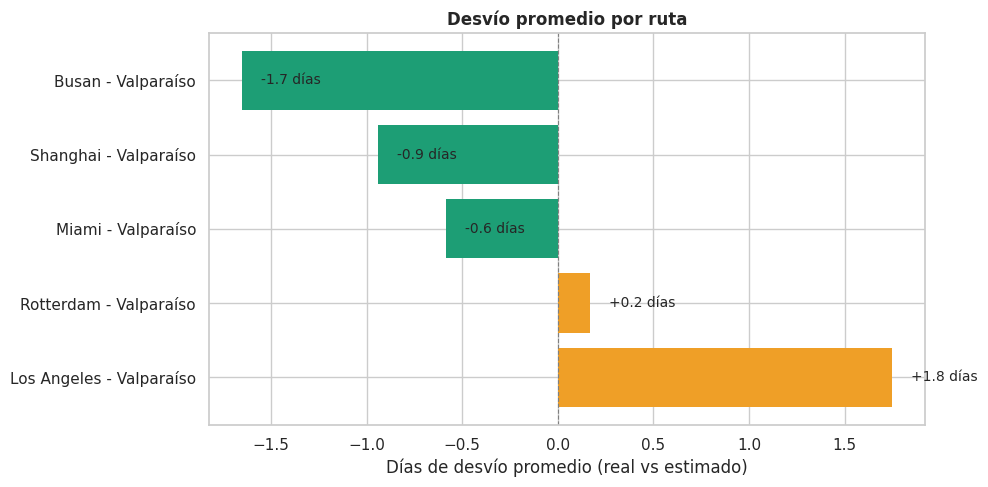

In [5]:
desvio_ruta = df.groupby('ruta')['desvio_dias'].mean().sort_values(ascending=False)

colores = ['#E24B4A' if v > 2 else '#EF9F27' if v > 0 else '#1D9E75' for v in desvio_ruta]

fig, ax = plt.subplots()
bars = ax.barh(desvio_ruta.index, desvio_ruta.values, color=colores, edgecolor='none')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Días de desvío promedio (real vs estimado)')
ax.set_title('Desvío promedio por ruta', fontweight='bold')

for bar, val in zip(bars, desvio_ruta.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f} días', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('data/desvio_por_ruta.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado')

### 3.2 Variabilidad por naviera (boxplot)

/tmp/ipykernel_26336/2652246622.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


FileNotFoundError: [Errno 2] No such file or directory: 'data/variabilidad_naviera.png'

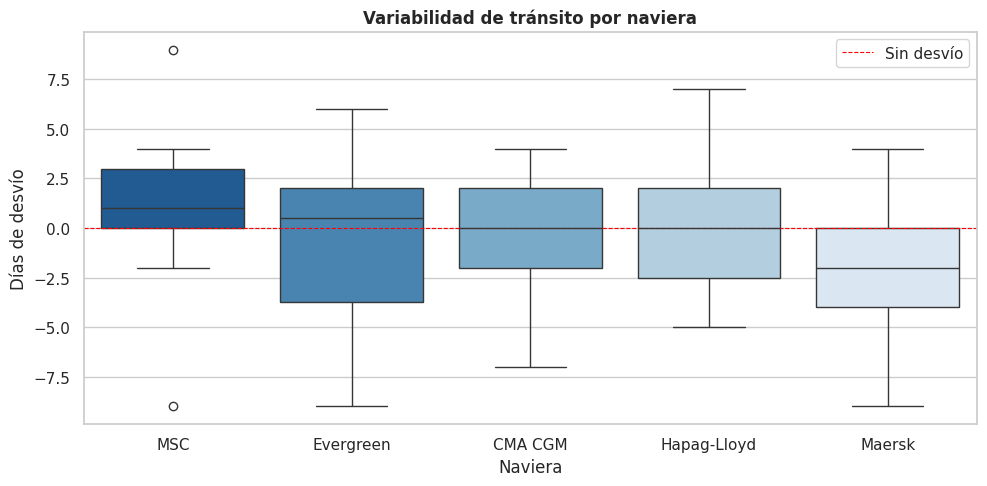

In [6]:
orden_navieras = df.groupby('naviera')['desvio_dias'].median().sort_values(ascending=False).index

fig, ax = plt.subplots()
sns.boxplot(
    data=df, x='naviera', y='desvio_dias',
    order=orden_navieras,
    palette='Blues_r', ax=ax
)
ax.axhline(0, color='red', linewidth=0.8, linestyle='--', label='Sin desvío')
ax.set_xlabel('Naviera')
ax.set_ylabel('Días de desvío')
ax.set_title('Variabilidad de tránsito por naviera', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('data/variabilidad_naviera.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado')

### 3.3 Retrasos por mes (estacionalidad)

FileNotFoundError: [Errno 2] No such file or directory: 'data/estacionalidad.png'

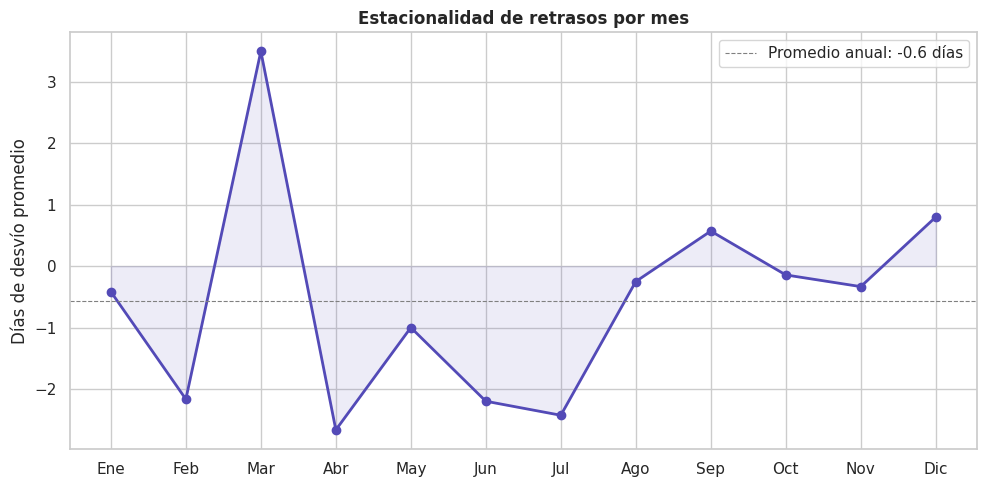

In [7]:
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
retraso_mes = df.groupby('mes')['desvio_dias'].mean()

fig, ax = plt.subplots()
ax.plot(retraso_mes.index, retraso_mes.values,
        marker='o', color='#534AB7', linewidth=2, markersize=6)
ax.fill_between(retraso_mes.index, retraso_mes.values, alpha=0.1, color='#534AB7')
ax.axhline(retraso_mes.mean(), color='gray', linewidth=0.8,
           linestyle='--', label=f'Promedio anual: {retraso_mes.mean():.1f} días')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.set_ylabel('Días de desvío promedio')
ax.set_title('Estacionalidad de retrasos por mes', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('data/estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado')

## 4. Conclusiones
_Segun la muestra analizada se puede observar que la ruta Los Angeles - Valparaíso es una de las rutas con mayor tasa de atrasos, seguido de la ruta Rotterdam - Valparaíso, considerar que la ruta mas expedita corresponde a la de Busan-Valparaiso. Ocurre un factor interesante ya que la naviera con el promedio mas bajo en cantidad de atrasos corresponde a la naviera CMA CGM, la cual suele mantener sus horarios en la muestra analisada, mientras que por otra parte, la naviera Maersk menos días de lo señalado, lo cual en logistica dependiento del caso puede ser beneficioso. Particularmente en el mes de marzo se encuentra uno de los peaks mas altos, lo que puede deberse a la alta demanda y trafico que suele verse en esa fecha, al igual que en septiembre, que es el segundo punto mas alto, particularmente despues de el peak se suele ver una bajada abrupta en el mes de abril. Si bien se cuenta con un peak en marzo de poco mas de 3 días, el promedio tiende a ser con menor cantidad de días de transito. Como operativo y analista de esta base de datos, recomendaria la priorizacion de proveedores donde se utilicen la ruta  Busan - Valparaiso, en conjunto de la naviera Maersk, dentro del periodo de Abril a Julio, ya que todos estos factores disminuyen el riesgo de el factor de atraso en el arribo de la nave._ 